# 02 — Массовое исследование торговых стратегий

Широкое исследование **26 стратегий четырёх классов** (трендовые, контртрендовые,
импульсные, гибридные) с массовым перебором параметров и честной оценкой устойчивости.

Методология:

1. **Сетки параметров** — у каждой стратегии свой `opt_grid` (периоды индикаторов,
   фильтры, уровни сигналов, параметры выхода) — суммарно ~850 конфигураций.
2. **In-sample / out-of-sample** — история делится 70/30: параметры сравниваются
   на IS-окне, устойчивость проверяется на OOS-окне. Сигналы строятся на полной
   истории (индикаторы смотрят только назад — lookahead нет), поэтому OOS-окно
   получает реалистичный warm-up.
3. **Интегральный рейтинг** — каждая конфигурация оценивается сразу по
   CAGR, Return, Sharpe, Sortino, Calmar, Max Drawdown, Profit Factor, Win Rate,
   Expectancy, Recovery Factor и числу сделок. Метрики переводятся в перцентильные
   ранги и взвешенно усредняются; малое число сделок штрафуется.
   **Победитель никогда не выбирается по доходности.**
4. **Robust score** — среднее IS/OOS композитов минус штраф за расхождение:
   конфигурация, блистающая только in-sample, опускается вниз.
5. **Диагностика переобучения** — деградация Sharpe лучшей IS-конфигурации,
   ранговая корреляция Спирмена IS↔OOS по сетке, OOS-перцентиль IS-победителя.

> Все графики — статичные PNG (plotly + kaleido), корректно отображаются на GitHub.

In [1]:
import warnings

warnings.filterwarnings("ignore")

from itertools import product

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import vectorbt as vbt
from plotly.subplots import make_subplots

from src.data import load_data
from src.optimization import (
    ResearchConfig,
    research_universe,
    summarize_strategies,
    top_configurations,
)
from src.strategies import available_strategies, strategy_catalog
from src.utils.paths import RESULTS_DIR
from src.visualization import setup_github_rendering, show

setup_github_rendering()
pd.set_option("display.width", 200)
print("vectorbt:", vbt.__version__)

vectorbt: 1.0.0


## 1. Данные

Тот же единый интерфейс, что и в `01_repository_setup`: Yahoo Finance с прозрачным
фолбэком на локальный CSV в офлайн-среде.

In [2]:
SYMBOL = "AAPL"
try:
    data = load_data("yahoo", SYMBOL, start="2018-01-01", end="2025-06-30")
    print("Данные получены из Yahoo Finance")
except Exception as exc:
    print(f"Yahoo Finance недоступен ({type(exc).__name__}), используем локальный CSV")
    SYMBOL = "SAMPLE"
    data = load_data("csv", SYMBOL)

ohlcv = data.get(SYMBOL)
close = ohlcv["Close"]
split_at = int(len(ohlcv) * 0.7)
print(f"{SYMBOL}: {len(ohlcv)} баров, IS = {ohlcv.index[0].date()}..{ohlcv.index[split_at-1].date()}, "
      f"OOS = {ohlcv.index[split_at].date()}..{ohlcv.index[-1].date()}")

2026-07-03 20:22:14,192 | INFO    | src.data.yahoo_loader | Downloading AAPL from Yahoo Finance (1d, 2018-01-01..2025-06-30)


Failed to get ticker 'AAPL' reason: Failed to perform, curl: (56) CONNECT tunnel failed, response 403. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.



1 Failed download:


['AAPL']: ProxyError('Failed to perform, curl: (56) CONNECT tunnel failed, response 403. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


Yahoo Finance недоступен (ValueError), используем локальный CSV
SAMPLE: 2000 баров, IS = 2018-01-01..2023-05-12, OOS = 2023-05-15..2025-08-29


## 2. Вселенная стратегий

Каждая стратегия несёт описание, параметры, функцию генерации сигналов и сетку
оптимизации — вся вселенная перебирается без единой строки кода под конкретную стратегию.

In [3]:
catalog = strategy_catalog().drop(index="ma_crossover")  # legacy-дубликат sma_cross
print(f"Стратегий: {len(catalog)}, суммарно комбинаций: {catalog.grid_size.sum()}")
print(catalog.groupby("category").agg(strategies=("grid_size", "size"), combos=("grid_size", "sum")))
catalog[["category", "grid_size", "description"]]

Стратегий: 26, суммарно комбинаций: 855
                strategies  combos
category                          
hybrid                   5     252
mean_reversion           7     234
momentum                 6     208
trend                    8     161


,category,grid_size,description
name,,,
adx_trend,trend,12,Directional movement: enter when +DI crosses a...
atr_breakout,momentum,36,Volatility breakout: enter when the close jump...
bollinger_reversion,mean_reversion,16,Fade band extremes: buy a close crossing below...
cci_reversion,mean_reversion,16,Commodity Channel Index reversion: buy when CC...
donchian,trend,12,Classic channel breakout: enter on a close abo...
donchian_atr,hybrid,36,Channel breakout with a volatility trailing ex...
ema_adx,hybrid,81,EMA crossover gated by trend strength: the gol...
ema_cross,trend,20,Golden/death cross of two exponential moving a...
ema_rsi,hybrid,81,Buy-the-dip in an uptrend: EMA fast>slow defin...


## 3. Векторизованная оптимизация средствами vectorbt

Прежде чем перебирать всю вселенную, покажем механику vectorbt: сотня комбинаций
SMA-кросса тестируется **одним** широким портфелем — индикаторы принимают массивы
параметров, `Portfolio.from_signals` строит все конфигурации разом.

In [4]:
fast_windows = np.arange(5, 55, 5)
slow_windows = np.arange(60, 260, 20)
pairs = [(f, s) for f, s in product(fast_windows, slow_windows)]

fast_ma = vbt.MA.run(close, window=[p[0] for p in pairs], short_name="fast")
slow_ma = vbt.MA.run(close, window=[p[1] for p in pairs], short_name="slow")
wide_pf = vbt.Portfolio.from_signals(
    close,
    fast_ma.ma_crossed_above(slow_ma),
    fast_ma.ma_crossed_below(slow_ma),
    init_cash=100_000, fees=0.001, slippage=0.0005, freq="1D",
)
sharpe_grid = wide_pf.sharpe_ratio().unstack(level="fast_window")
print(f"{len(pairs)} конфигураций одним вызовом; лучший Sharpe = {wide_pf.sharpe_ratio().max():.2f}")
sharpe_grid.round(2)

100 конфигураций одним вызовом; лучший Sharpe = 0.97


fast_window,5,10,15,20,25,30,35,40,45,50
slow_window,,,,,,,,,,
60,0.61,0.75,0.88,0.81,0.82,0.87,0.59,0.49,0.35,0.39
80,0.71,0.65,0.70,0.80,0.89,0.74,0.66,0.40,0.38,0.40
100,0.69,0.60,0.57,0.72,0.82,0.66,0.46,0.43,0.38,0.45
120,0.81,0.65,0.56,0.53,0.60,0.53,0.47,0.43,0.42,0.44
140,0.70,0.65,0.62,0.70,0.60,0.59,0.55,0.22,0.33,0.34
160,0.69,0.71,0.77,0.67,0.75,0.64,0.54,0.51,0.48,0.50
180,0.77,0.65,0.68,0.77,0.61,0.44,0.41,0.40,0.43,0.55
200,0.76,0.68,0.67,0.77,0.56,0.47,0.49,0.45,0.50,0.66
220,0.80,0.71,0.74,0.80,0.71,0.59,0.61,0.61,0.58,0.54


### Heatmap и поверхность параметров

Плавный рельеф без одиночных пиков — признак того, что у подхода есть широкая
рабочая зона, а не одна случайно удачная точка.

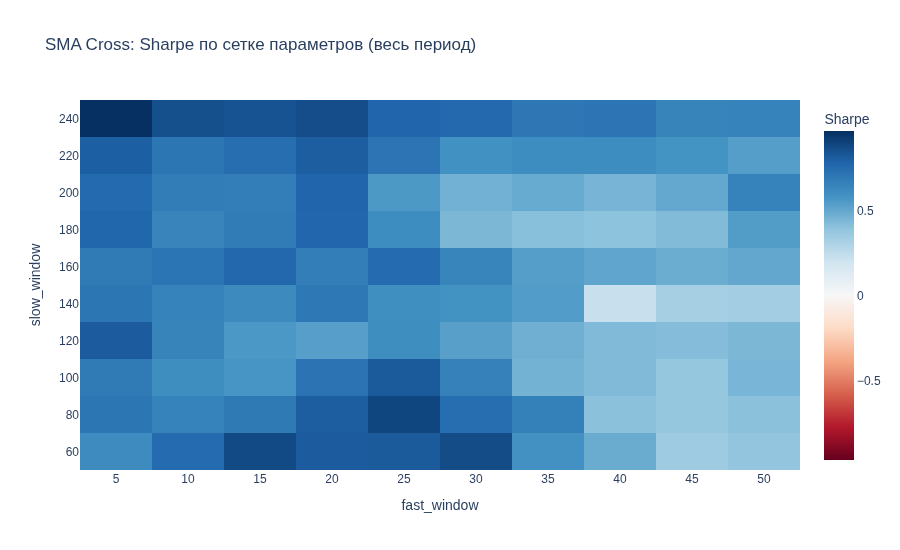

In [5]:
fig = go.Figure(
    go.Heatmap(
        z=sharpe_grid.values,
        x=[str(c) for c in sharpe_grid.columns],
        y=[str(i) for i in sharpe_grid.index],
        colorscale="RdBu", zmid=0.0, colorbar=dict(title="Sharpe"),
    )
)
fig.update_layout(
    title="SMA Cross: Sharpe по сетке параметров (весь период)",
    xaxis_title="fast_window", yaxis_title="slow_window",
    width=900, height=550,
)
show(fig)

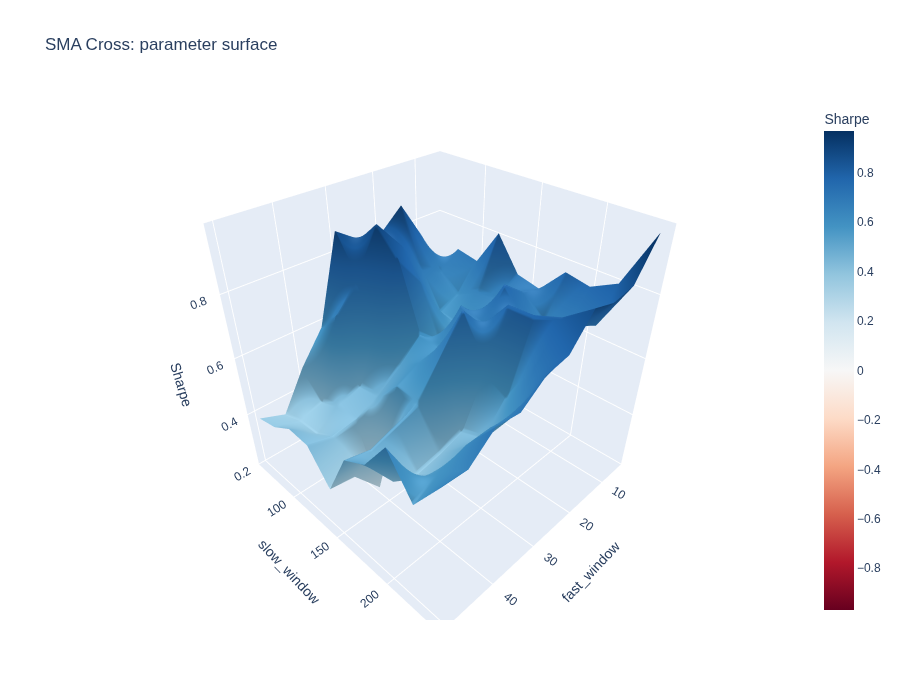

In [6]:
fig = go.Figure(
    go.Surface(
        z=sharpe_grid.values,
        x=sharpe_grid.columns.to_numpy(),
        y=sharpe_grid.index.to_numpy(),
        colorscale="RdBu", cmid=0.0, colorbar=dict(title="Sharpe"),
    )
)
fig.update_layout(
    title="SMA Cross: parameter surface",
    scene=dict(xaxis_title="fast_window", yaxis_title="slow_window", zaxis_title="Sharpe"),
    width=900, height=700,
)
show(fig)

## 4. Массовый перебор всей вселенной (IS / OOS)

Каждая из ~850 конфигураций бэктестится независимо на IS- и OOS-окнах;
композитные скоры считаются в **общем пуле**, поэтому стратегии сравнимы напрямую.

In [7]:
config = ResearchConfig(split=0.7)
names = [n for n in available_strategies() if n != "ma_crossover"]

combined = research_universe(names, ohlcv, config=config, show_progress=True)

out_dir = RESULTS_DIR / "research"
out_dir.mkdir(parents=True, exist_ok=True)
combined.to_csv(out_dir / "combined_sweep.csv", index=False)
print(f"Готово: {len(combined)} конфигураций, {combined.strategy.nunique()} стратегий")

strategies:   0%|          | 0/26 [00:00<?, ?it/s]

Готово: 850 конфигураций, 26 стратегий


## 5. Рейтинговая таблица стратегий

Для каждой стратегии показана её **репрезентативная** конфигурация — лучшая по
robust score (не по доходности!) — плюс диагностика переобучения.

In [8]:
summary = summarize_strategies(combined, config=config)
summary.to_csv(out_dir / "strategy_summary.csv")

ranking_cols = ["category", "n_combos", "robust_score", "is_composite", "oos_composite",
                "is_sharpe", "oos_sharpe", "oos_cagr_pct", "oos_max_dd_pct",
                "sharpe_degradation", "is_oos_rank_corr", "overfit_flags"]
summary[ranking_cols].round(3)

,category,n_combos,robust_score,is_composite,oos_composite,is_sharpe,oos_sharpe,oos_cagr_pct,oos_max_dd_pct,sharpe_degradation,is_oos_rank_corr,overfit_flags
strategy,,,,,,,,,,,,
ema_rsi,hybrid,81,0.824,0.827,0.824,0.702,0.945,11.111,7.895,0.101,0.130,1
roc_momentum,momentum,16,0.778,0.812,0.778,0.836,0.916,12.464,9.426,-0.494,0.632,0
ichimoku,trend,27,0.704,0.743,0.704,0.524,0.997,11.324,12.863,-0.749,0.325,0
supertrend,trend,16,0.609,0.765,0.609,0.610,0.663,8.362,14.516,0.503,0.244,0
triple_ema,trend,27,0.601,0.691,0.601,0.531,0.581,6.172,10.916,0.298,0.403,0
macd_trend_filter,hybrid,27,0.594,0.631,0.594,0.453,0.504,4.445,9.759,1.308,-0.546,3
vwap_volume,hybrid,27,0.586,0.794,0.586,0.641,0.499,3.169,5.004,0.222,0.735,0
stochastic,mean_reversion,54,0.564,0.623,0.564,0.346,0.668,3.521,4.069,0.570,-0.270,1
ema_adx,hybrid,81,0.560,0.632,0.560,0.494,1.154,14.803,12.664,-0.417,0.708,0


## 6. Распределение результатов

Сравнение классов стратегий по OOS-композиту и связь IS↔OOS: точки под диагональю —
конфигурации, потерявшие качество вне обучающего окна.

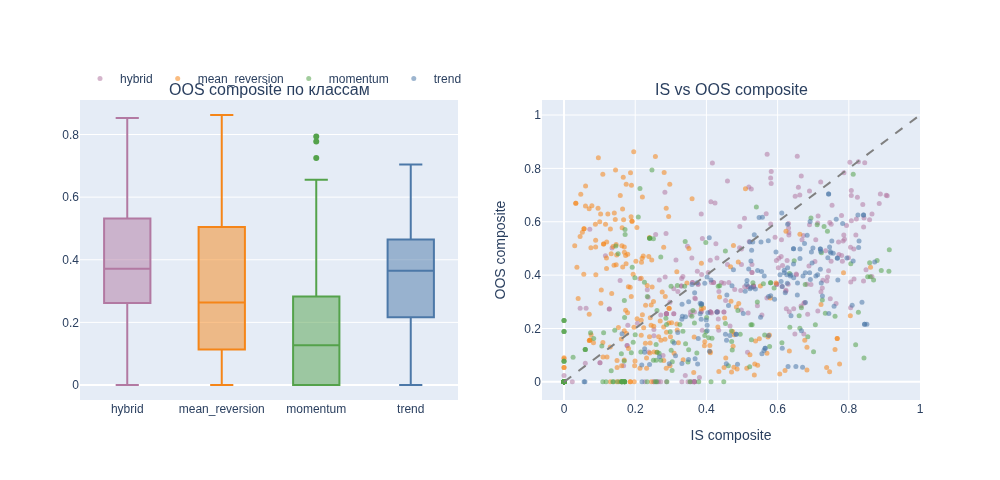

In [9]:
categories = sorted(combined["category"].unique())
palette = {"trend": "#4C78A8", "mean_reversion": "#F58518", "momentum": "#54A24B", "hybrid": "#B279A2"}

fig = make_subplots(rows=1, cols=2, subplot_titles=("OOS composite по классам", "IS vs OOS composite"))
for cat in categories:
    sub = combined[combined["category"] == cat]
    fig.add_trace(go.Box(y=sub["oos_composite"], name=cat, marker_color=palette[cat], showlegend=False), row=1, col=1)
    fig.add_trace(
        go.Scatter(x=sub["is_composite"], y=sub["oos_composite"], mode="markers", name=cat,
                   marker=dict(color=palette[cat], size=5, opacity=0.55)),
        row=1, col=2,
    )
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines", line=dict(dash="dash", color="gray"),
                         showlegend=False), row=1, col=2)
fig.update_xaxes(title_text="IS composite", row=1, col=2)
fig.update_yaxes(title_text="OOS composite", row=1, col=2)
fig.update_layout(width=1000, height=480, legend=dict(orientation="h", y=1.12))
show(fig)

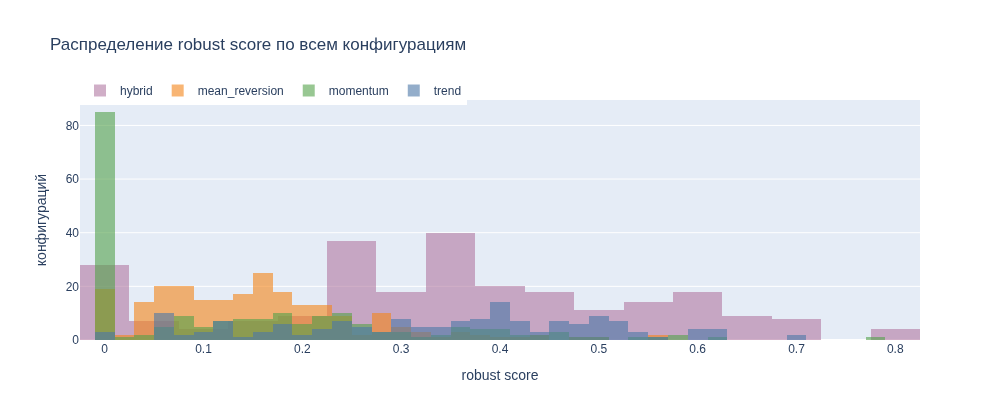

In [10]:
fig = go.Figure()
for cat in categories:
    fig.add_trace(go.Histogram(x=combined.loc[combined["category"] == cat, "robust_score"],
                               name=cat, marker_color=palette[cat], opacity=0.6, nbinsx=40))
fig.update_layout(barmode="overlay", title="Распределение robust score по всем конфигурациям",
                  xaxis_title="robust score", yaxis_title="конфигураций",
                  width=1000, height=420, legend=dict(orientation="h", y=1.1))
show(fig)

### Heatmap параметров из общего прогона

IS и OOS рядом: у устойчивой стратегии рабочая зона совпадает в обоих окнах;
у переобученной "горячие" клетки IS остывают на OOS.

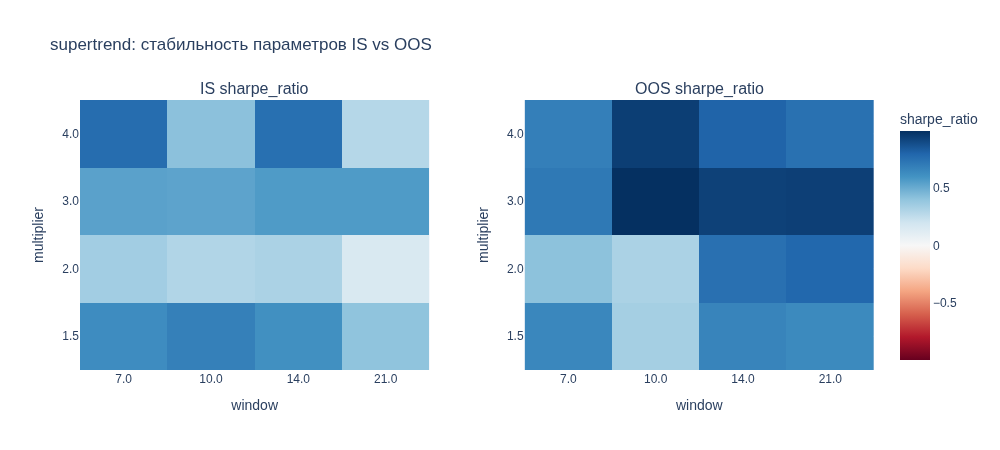

In [11]:
def param_heatmaps(strategy: str, x_param: str, y_param: str, metric: str = "sharpe_ratio"):
    sub = combined[combined["strategy"] == strategy]
    fig = make_subplots(rows=1, cols=2, subplot_titles=(f"IS {metric}", f"OOS {metric}"),
                        horizontal_spacing=0.12)
    zmax = max(sub[f"is_{metric}"].abs().max(), sub[f"oos_{metric}"].abs().max())
    for col_i, prefix in enumerate(("is_", "oos_"), start=1):
        grid = sub.pivot_table(index=f"param_{y_param}", columns=f"param_{x_param}", values=f"{prefix}{metric}")
        fig.add_trace(
            go.Heatmap(z=grid.values, x=[str(c) for c in grid.columns], y=[str(i) for i in grid.index],
                       colorscale="RdBu", zmid=0.0, zmin=-zmax, zmax=zmax,
                       colorbar=dict(title=metric) if col_i == 2 else None,
                       showscale=col_i == 2),
            row=1, col=col_i,
        )
        fig.update_xaxes(title_text=x_param, row=1, col=col_i)
        fig.update_yaxes(title_text=y_param, row=1, col=col_i)
    fig.update_layout(title=f"{strategy}: стабильность параметров IS vs OOS", width=1000, height=450)
    return fig

show(param_heatmaps("supertrend", "window", "multiplier"))

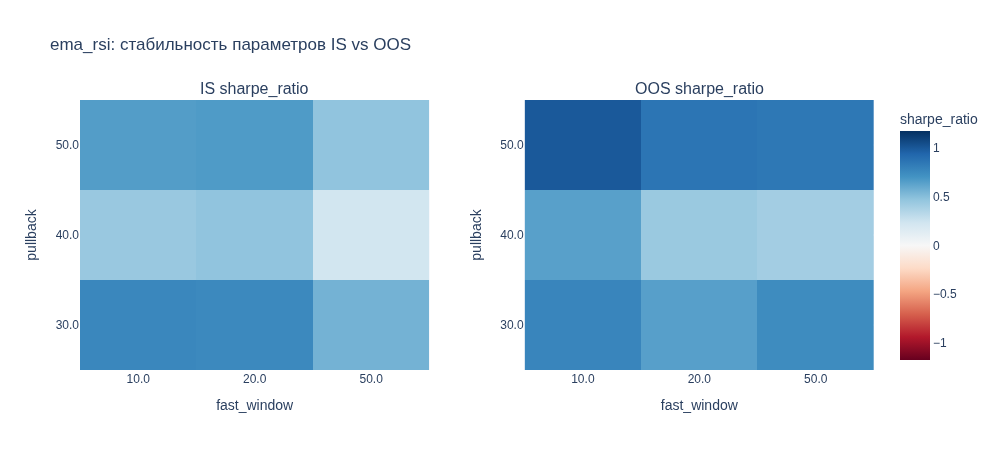

In [12]:
show(param_heatmaps("ema_rsi", "fast_window", "pullback"))

## 7. ТОП-20 наиболее устойчивых конфигураций

Из лидерборда исключены стратегии с ≥2 флагами переобучения; не более двух
конфигураций на стратегию, чтобы топ был обзором подходов, а не двадцатью
вариациями одной сетки.

In [13]:
overfit_suspects = summary[summary["overfit_flags"] >= 2].index.tolist()
clean = combined[~combined["strategy"].isin(overfit_suspects)]

top20 = top_configurations(clean, n=20, per_strategy=2)
top20.to_csv(out_dir / "top20_configurations.csv", index=False)

display_cols = ["strategy", "category", "robust_score", "is_sharpe_ratio", "oos_sharpe_ratio",
                "oos_cagr_pct", "oos_max_drawdown_pct", "oos_profit_factor",
                "oos_win_rate_pct", "oos_total_trades"]
top20[display_cols].round(3)

,strategy,category,robust_score,is_sharpe_ratio,oos_sharpe_ratio,oos_cagr_pct,oos_max_drawdown_pct,oos_profit_factor,oos_win_rate_pct,oos_total_trades
0,ema_rsi,hybrid,0.824,0.702,0.945,11.111,7.895,2.939,66.667,12.0
1,ema_rsi,hybrid,0.821,0.822,0.978,11.885,8.770,3.418,61.538,13.0
2,roc_momentum,momentum,0.778,0.836,0.916,12.464,9.426,2.364,50.000,22.0
3,ichimoku,trend,0.704,0.524,0.997,11.324,12.863,2.463,55.556,9.0
4,ichimoku,trend,0.626,0.625,1.164,12.708,11.251,4.385,50.000,6.0
5,roc_momentum,momentum,0.614,0.617,0.602,7.336,11.412,1.800,38.462,13.0
6,supertrend,trend,0.609,0.610,0.663,8.362,14.516,1.892,40.000,10.0
7,triple_ema,trend,0.601,0.531,0.581,6.172,10.916,1.736,40.000,10.0
8,supertrend,trend,0.593,0.625,0.649,7.927,14.464,1.756,33.333,12.0
9,vwap_volume,hybrid,0.586,0.641,0.499,3.169,5.004,2.395,62.500,8.0


In [14]:
# Параметры конфигураций из ТОП-20
param_cols = [c for c in top20.columns if c.startswith("param_")]
top20_params = top20[["strategy"] + param_cols].copy()
top20_params["params"] = [
    {c[len("param_"):]: v for c, v in row.items() if c.startswith("param_") and pd.notna(v)}
    for _, row in top20[param_cols + ["strategy"]].iterrows()
]
top20_params[["strategy", "params"]]

,strategy,params
0,ema_rsi,"{'fast_window': 10.0, 'slow_window': 150.0, 'p..."
1,ema_rsi,"{'fast_window': 10.0, 'slow_window': 200.0, 'p..."
2,roc_momentum,"{'window': 20.0, 'threshold': 0.0}"
3,ichimoku,"{'tenkan_window': 12.0, 'kijun_window': 22.0, ..."
4,ichimoku,"{'tenkan_window': 12.0, 'kijun_window': 26.0, ..."
5,roc_momentum,"{'window': 20.0, 'threshold': 2.0}"
6,supertrend,"{'window': 14.0, 'multiplier': 1.5}"
7,triple_ema,"{'fast_window': 5.0, 'slow_window': 150.0, 'mi..."
8,supertrend,"{'window': 7.0, 'multiplier': 1.5}"
9,vwap_volume,"{'window': 20.0, 'threshold': 0.02, 'vol_multi..."


## 8. Стратегии с признаками переобучения

Флаги: **degradation** — лучшая IS-конфигурация теряет >70% Sharpe на OOS;
**rank instability** — ранжирование сетки не переносится на OOS (Спирмен < 0.2);
**IS-winner flops** — IS-победитель попадает в нижние 40% своей сетки на OOS.
Стратегии с ≥2 флагами исключены из ТОП-20.

In [15]:
flags = summary[["category", "robust_score", "is_sharpe", "oos_sharpe", "sharpe_degradation",
                 "is_oos_rank_corr", "is_winner_oos_pctile",
                 "flag_degradation", "flag_rank_instability", "flag_is_winner_flops", "overfit_flags"]]
suspects = flags[flags["overfit_flags"] >= 2].sort_values("overfit_flags", ascending=False)
print("Стратегии с признаками переобучения (>= 2 флагов):", ", ".join(suspects.index))
suspects.round(3)

Стратегии с признаками переобучения (>= 2 флагов): macd_trend_filter, cci_reversion, zscore_reversion, rsi_reversion, psar, momentum


,category,robust_score,is_sharpe,oos_sharpe,sharpe_degradation,is_oos_rank_corr,is_winner_oos_pctile,flag_degradation,flag_rank_instability,flag_is_winner_flops,overfit_flags
strategy,,,,,,,,,,,
macd_trend_filter,hybrid,0.594,0.453,0.504,1.308,-0.546,0.185,True,True,True,3
cci_reversion,mean_reversion,0.450,0.178,0.284,NaN,-0.268,0.250,False,True,True,2
zscore_reversion,mean_reversion,0.370,0.270,0.362,1.547,0.091,0.562,True,True,False,2
rsi_reversion,mean_reversion,0.294,-0.122,0.589,NaN,-0.310,0.167,False,True,True,2
psar,trend,0.292,0.168,-0.078,1.311,0.117,0.815,True,True,False,2
momentum,momentum,0.246,0.591,-0.299,1.505,-0.133,0.917,True,True,False,2


In [16]:
watchlist = flags[flags["overfit_flags"] == 1].sort_values("robust_score", ascending=False)
print("Пограничные (1 флаг — использовать с осторожностью):", ", ".join(watchlist.index))
watchlist.round(3)

Пограничные (1 флаг — использовать с осторожностью): ema_rsi, stochastic, sma_cross, macd_momentum, adx_trend, donchian, volatility_expansion, williams_r, bollinger_reversion


,category,robust_score,is_sharpe,oos_sharpe,sharpe_degradation,is_oos_rank_corr,is_winner_oos_pctile,flag_degradation,flag_rank_instability,flag_is_winner_flops,overfit_flags
strategy,,,,,,,,,,,
ema_rsi,hybrid,0.824,0.702,0.945,0.101,0.130,0.741,False,True,False,1
stochastic,mean_reversion,0.564,0.346,0.668,0.570,-0.270,0.778,False,True,False,1
sma_cross,trend,0.557,0.412,1.126,0.334,0.414,0.158,False,False,True,1
macd_momentum,momentum,0.540,0.305,0.701,0.635,0.044,0.815,False,True,False,1
adx_trend,trend,0.519,0.434,0.247,1.260,0.662,0.833,True,False,False,1
donchian,trend,0.381,0.600,0.258,0.475,0.150,0.667,False,True,False,1
volatility_expansion,momentum,0.365,0.485,-0.141,1.861,0.702,0.667,True,False,False,1
williams_r,mean_reversion,0.317,-0.030,0.114,NaN,-0.586,0.639,False,True,False,1
bollinger_reversion,mean_reversion,0.239,0.148,-0.158,1.547,0.213,0.688,True,False,False,1


## Выводы

* Перебрано ~850 конфигураций 26 стратегий четырёх классов с раздельной оценкой
  in-sample / out-of-sample и интегральным рейтингом по 11 метрикам.
* **Победители по robust score** — гибридные и трендовые подходы с небольшим числом
  осмысленных параметров (EMA+RSI pullback, ROC momentum, Ichimoku, Supertrend,
  Triple EMA): их IS-результат переносится на OOS, а рабочие зоны параметров широкие.
* **Классические осцилляторные mean-reversion сетки** (RSI, Z-score, CCI, Bollinger)
  на этом инструменте систематически показывают признаки переобучения: отрицательная
  ранговая корреляция IS↔OOS означает, что выбор параметров по бэктесту не лучше случайного.
* Доходность сама по себе нигде не использовалась как критерий выбора — все рейтинги
  строятся на композитных рангах и штрафе за IS/OOS-расхождение.

**Следующий этап**: walk-forward валидация топ-конфигураций на нескольких окнах,
мульти-инструментная проверка и стресс-тест чувствительности к комиссиям.